## Section 1 Figures

This notebook compiles the plots to make section 1. To store the plots in a different directory, specify `PAPER_FIGURES_ROOT` to your target path.

In [1]:
import fitsio as fio
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
from mocpy import MOC
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table, vstack
from pathlib import Path

import src.statistics.corrfiles as cf
import src.analysis.plots as plots

DESI_ROOT_DR2 = Path('/global/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/nonKP')
PAPER_FIGURES_ROOT = Path('/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/')
if not PAPER_FIGURES_ROOT.exists():
    PAPER_FIGURES_ROOT.mkdir(parents=True)
moc_list = sorted([
    Path(
        '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/', 
        f'hsc_moc{i+1}.fits'
    )
    for i in range(0, 4)
])
cmap_hsc = plt.get_cmap('plasma')
cmap_desi = plt.get_cmap('viridis')

# plot infrastructure
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

In [2]:
hsc_bins = np.arange(0.3, 1.8, 0.3)
hsc = fio.FITS(str(Path(cf.fetch_hsc_files()).with_suffix('')) + '_withflags.fits')[1].read()
photoz = hsc['dnnz_photoz_best']
zbin = hsc['z_bin']

In [3]:
caps = ['NGC', 'SGC']
tgts_dr1 = ['BGS_ANY', 'LRG', 'ELG_LOPnotqso', 'QSO']
desi_tgts_dr1 = {
    (tgt, cap) :
    cf.fetch_desi_files(tgt=tgt, version='DR1', cap=cap)
    for tgt in tgts_dr1
    for cap in caps
}
tgts_dr2 = ['BGS_ANY', 'LRG', 'ELGnotqso', 'QSO']
desi_tgts_dr2 = {
    (tgt, cap) :
    cf.fetch_desi_files(tgt=tgt, version='DR2', cap=cap)
    for tgt in tgts_dr2
    for cap in caps
}

desi_tbls_dr1 = {}
print('Reading DR2 catalogs...')
for tracer in tgts_dr1:
    desi_cat = [desi_tgts_dr1[(tracer, cap)] for cap in caps]
    dt = vstack([
        Table(fio.read(dc, columns=['RA', 'DEC', 'Z']))
        for dc in desi_cat
    ])
    desi_tbls_dr1[tracer] = dt
desi_dr1 = vstack(list(desi_tbls_dr1.values()))

desi_tbls_dr2 = {}
print('Reading DR1 catalogs...')
for tracer in tgts_dr2:
    desi_cat = [desi_tgts_dr2[(tracer, cap)] for cap in caps]
    dt = vstack([
        Table(fio.read(dc, columns=['RA', 'DEC', 'Z']))
        for dc in desi_cat
    ])
    desi_tbls_dr2[tracer] = dt
desi_dr2 = vstack(list(desi_tbls_dr2.values()))

Reading DR2 catalogs...
Reading DR1 catalogs...


In [4]:
def sample_desi_on_moc(
        desi_catalog : Table, 
        desi_tbls : dict
    ):
    coords_desi = SkyCoord(
        ra=desi_catalog['RA'] * u.deg, 
        dec=desi_catalog['DEC'] * u.deg, 
        frame='icrs'
    )
    tbl_in_moc_n = {
        k: np.zeros(len(v), dtype=bool) for k, v in desi_tbls.items()
    }
    desi_in_moc_n = np.zeros(len(coords_desi), dtype=bool)
    for mocf in moc_list:
        print(f'Processing MOC file: {mocf}')
        moc = MOC.from_fits(mocf)
        desi_in_moc_n |= moc.contains_skycoords(coords_desi)
        for k, v in desi_tbls.items():
            tbl_in_moc_n[k] |= moc.contains_skycoords(
                SkyCoord(ra=v['RA'] * u.deg, dec=v['DEC'] * u.deg, frame='icrs')
            )
    desi_in_hsc = desi_catalog[
        np.flatnonzero(desi_in_moc_n)
    ]
    tbl_in_hsc = {
        k: v[np.flatnonzero(tbl_in_moc_n[k])] 
        for k, v in desi_tbls.items()
    }
    return desi_in_hsc, tbl_in_hsc

In [5]:
desi_in_hsc_dr1, tbl_in_hsc_dr1 = sample_desi_on_moc(desi_dr1, desi_tbls_dr1)
desi_in_hsc_dr2, tbl_in_hsc_dr2 = sample_desi_on_moc(desi_dr2, desi_tbls_dr2)

Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc1.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc2.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc3.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc4.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc1.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc2.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc3.fits
Processing MOC file: /global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/mocs/hsc_moc4.fits


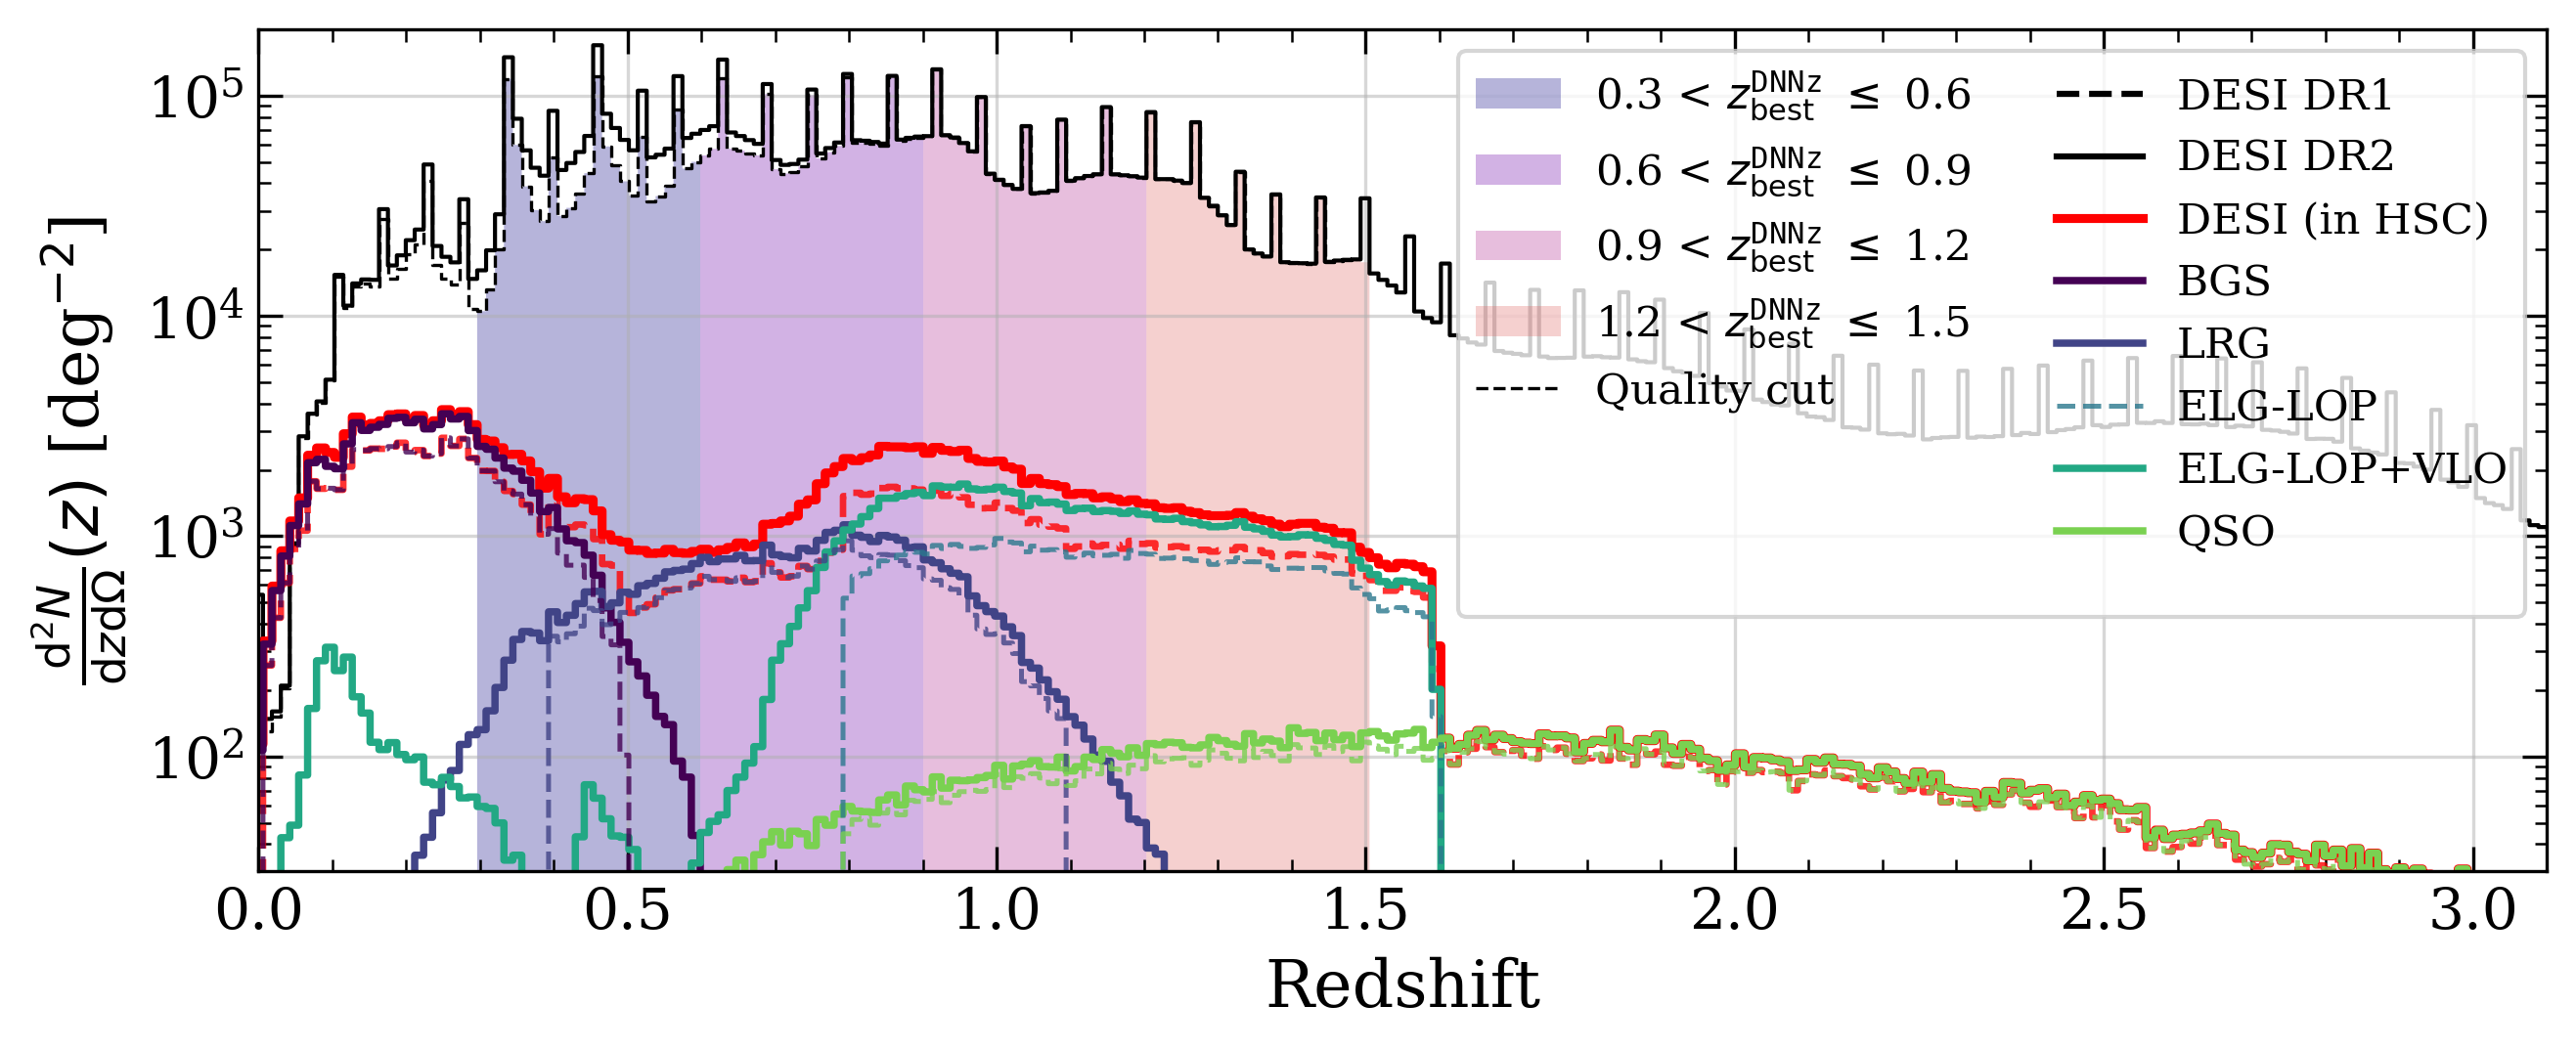

In [52]:
total_area_deg2 = 416 # effective area of HSC in deg^2
show_nocalib = False # whether to show the HSC histograms without calibration aswell

tracer_trad = {
    'BGS_ANY' : 'BGS',
    'LRG' : 'LRG',
    'ELG_LOPnotqso' : 'ELG-LOP',
    'ELGnotqso' : 'ELG-LOP+VLO',
    'QSO' : 'QSO'
}
dr_styles = {
    'DR1': {
        'linestyle': '--', 'color_total': 'red', 'alpha': 0.8, 'linewidth': 1.2
        },
    'DR2': {
        'linestyle': '-', 'color_total': 'red', 'alpha': 1, 'linewidth': 1.8
        }
}

with pm.make_plot('density_z', figsize=(9, 3.8), show=True) as (fig, ax):
    global_bins = np.linspace(0, 7, 580)
    bin_centers = global_bins[:-1]#(global_bins[:-1] + global_bins[1:]) / 2
    dz_bin = global_bins[1] - global_bins[0]
    norm_per_bin = total_area_deg2 * dz_bin

    quality_mask = (
        ((hsc['dnnz_photoz_err95_max'] - hsc['dnnz_photoz_err95_min']) < 2.7)
        & ((hsc['mizuki_photoz_err95_max'] - hsc['mizuki_photoz_err95_max']) < 2.7)
    )

    # Plot HSC histograms first - use only the zbin column for consistency
    for i in range(1, len(hsc_bins)):
        zbin_mask = (zbin == i)
        if show_nocalib:
            # Use the continuous redshift range for the no-calibration version
            z_mask = (photoz >= hsc_bins[i-1]) & (photoz < hsc_bins[i])
            counts, bins = np.histogram(photoz[z_mask], bins=global_bins)
            counts_per_area = counts / norm_per_bin
            ax.step(
                bin_centers,
                counts_per_area,
                where='mid',
                color=cmap_hsc((i-1) / len(hsc_bins)), 
                alpha=0.5
            )
        
        # Use the actual tomographic bin assignments for the final plot
        counts_zbin, _ = np.histogram(photoz[zbin_mask], bins=global_bins)
        counts_zbin_per_area = counts_zbin / norm_per_bin
        ax.fill_between(
            bin_centers,
            0, 
            counts_zbin_per_area,
            step='mid',
            label=(
                f'{hsc_bins[i-1]:.1f} < ' 
                + r'$z_{\mathrm{best}}^{\mathtt{DNNz}}$' 
                + r' $\leq$' 
                + f' {hsc_bins[i]:.1f}'
            ),
            color=cmap_hsc((i-1) / len(hsc_bins)),
            alpha=0.3,
            linewidth=0
        )
    # Total HSC histogram
    counts_total, _ = np.histogram(photoz, bins=global_bins)
    counts_total_per_area = counts_total / norm_per_bin
    ax.step(
        bin_centers, 
        counts_total_per_area,
        where='mid',
        color='black', 
        linewidth=1, 
        linestyle='-'
    )
    
    # Quality cut histogram scaled by area
    shear_selection = (quality_mask & (photoz <= 0.3)) | (zbin > 0)
    counts, bins = np.histogram(photoz[shear_selection], bins=global_bins)
    counts_per_area = counts / norm_per_bin
    # avoid 0s in the histogram
    nonzero = np.where(counts > 0)[0]
    if len(nonzero) > 0:
        start = nonzero[0]
        end = nonzero[-1]
        ax.step(
            bin_centers[start:end],  # use the same bin_centers array
            counts_per_area[start:end],
            where='mid',
            color='black',
            linestyle='--',
            linewidth=0.8,
            label='Quality cut'
        )
    
    # Plot DESI data for both DR1 and DR2
    dr_data = {
        'DR2': (tgts_dr2, desi_in_hsc_dr2, tbl_in_hsc_dr2),
        'DR1': (tgts_dr1, desi_in_hsc_dr1, tbl_in_hsc_dr1),
    }
    
    # Track which tracers we've seen for legend purposes
    tracers_plotted = set()
    
    # First pass: plot DESI totals (these will appear in legend before individual tracers)
    for dr_name, (tgts, desi_in_moc, tbls_in_moc) in dr_data.items():
        dr_style = dr_styles[dr_name]
        
        # DESI total histogram scaled by area
        counts_desi, _ = np.histogram(desi_in_moc['Z'], bins=global_bins)
        counts_desi_per_area = counts_desi / norm_per_bin
        ax.step(
            bin_centers,
            counts_desi_per_area,
            where='mid',
            color=dr_style['color_total'],
            label=f'DESI (in HSC)' if dr_name == 'DR2' else None,
            linewidth=2.2 if dr_name == 'DR2' else 1.6,
            linestyle=dr_style['linestyle'],
            alpha=dr_style['alpha']
        )
    
    # Second pass: plot individual tracers (these will appear after DESI totals in legend)
    for dr_name, (tgts, desi_in_moc, tbls_in_moc) in dr_data.items():
        dr_style = dr_styles[dr_name]
        
        # Individual DESI targets scaled by area
        for tracer_key, tbl in tbls_in_moc.items():
            tracer_display = tracer_trad.get(tracer_key, tracer_key)
            counts_target, _ = np.histogram(tbl['Z'], bins=global_bins)
            counts_target_per_area = counts_target / norm_per_bin

            # Get color for this tracer (consistent across DR1/DR2)
            tracer_idx = list(tracer_trad.keys()).index(tracer_key) if tracer_key in tracer_trad else 0
            color = cmap_desi(tracer_idx / len(tracer_trad))
            
            # Only add tracer to legend once, but plot both DR1 and DR2
            if tracer_key not in tracers_plotted:
                label = tracer_display
                tracers_plotted.add(tracer_key)
            else:
                label = None
                
            ax.step(
                bin_centers,
                counts_target_per_area,
                where='mid',
                color=color, 
                label=label, 
                linewidth=dr_style['linewidth'],
                linestyle=dr_style['linestyle'],
                alpha=dr_style['alpha']
            )

    handles, labels = ax.get_legend_handles_labels()
    legend_elements = []

    hsc_count = len(hsc_bins) - 1
    for i in range(hsc_count):
        legend_elements.append((handles[i], labels[i]))
    
    # 3. Quality cut
    quality_idx = labels.index('Quality cut') if 'Quality cut' in labels else None
    if quality_idx is not None:
        legend_elements.append((handles[quality_idx], labels[quality_idx]))
    
    # 4. Add DR1/DR2 linestyle indicators
    legend_elements.append((Line2D([0], [0], alpha=0, linestyle='-', linewidth=1.5), ' '))
    legend_elements.append((Line2D([0], [0], alpha=0, linestyle='-', linewidth=1.5), ' '))
    legend_elements.append((Line2D([0], [0], alpha=0, linestyle='-', linewidth=1.5), ' '))
    legend_elements.append((Line2D([0], [0], color='black', linestyle='--', linewidth=1.5), 'DESI DR1'))
    legend_elements.append((Line2D([0], [0], color='black', linestyle='-', linewidth=1.5), 'DESI DR2'))
    
    # 5. DESI totals (DR1 and DR2)
    for label in labels:
        if 'DESI' in label and '(in HSC)' in label:
            idx = labels.index(label)
            legend_elements.append((handles[idx], labels[idx]))
    
    # 6. Individual tracers
    tracer_names = list(tracer_trad.values())
    for tracer_name in tracer_names:
        if tracer_name in labels:
            idx = labels.index(tracer_name)
            legend_elements.append((handles[idx], labels[idx]))
    
    # Unpack the legend elements
    handles_final, labels_final = zip(*legend_elements)

    ax.set_yscale('log')
    ax.set_xlabel('Redshift', fontsize=16)
    if norm_per_bin == 1:
        #ax.set_ylabel(r'N(z)', fontsize=16)
        ax.set_ylabel(r'$\frac{\mathrm{d}N}{\mathrm{d}z}(z)$', fontsize=16)
    else:
        ax.set_ylabel(r'$\frac{\mathrm{d}^2N}{\mathrm{d}z\mathrm{d}\Omega}(z)$ [deg$^{-2}$]', fontsize=16)

    ax.xaxis.set_minor_locator(MultipleLocator(0.1))
    ax.grid(True)
    
    ax.legend(handles_final, labels_final, ncols=2, fontsize=10.5, loc='upper right')
    ax.set_xlim(0, 3.1)
    ax.set_ylim(3e1, 2e5)

(15.5, 25.5)

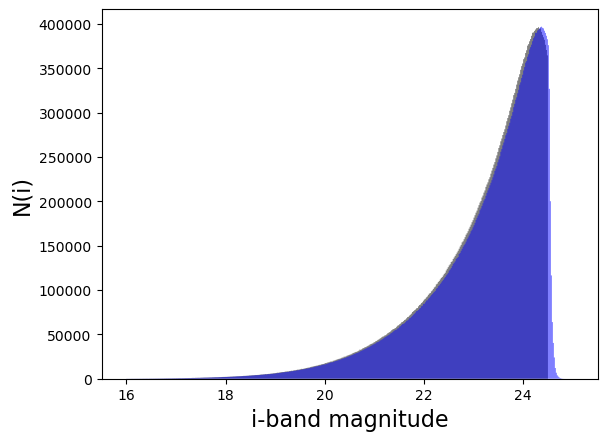

In [ ]:
imag_red = hsc['i_cm_mag'][:]
ai = hsc['a_i'][:]
imag = imag_red - ai

# Create i-band magnitude histogram using PlotManager
with pm.make_plot('i_band_magnitude', figsize=(8, 6)) as (fig, ax):
    ax.hist(
        imag, 
        bins=np.arange(16, 25, 0.02),
        color='black',
        histtype='stepfilled',
        linewidth=1.2,
        alpha=0.5,
        label='HSC i-band'
    )
    ax.hist(
        imag_red, 
        bins=np.arange(16, 25, 0.02),
        color='blue',
        histtype='stepfilled',
        linewidth=1.2,
        alpha=0.5,
        label='HSC i-band (redshifted)'
    )
    ax.set_xlabel('i-band magnitude', fontsize=16)
    ax.set_ylabel('N(i)', fontsize=16)
    ax.set_xlim(15.5, 25.5)
    ax.legend()

Processing z-bin 0
Number of objects in z-bin 0: 9146157
Processing z-bin 1
Number of objects in z-bin 1: 5889826
Processing z-bin 2
Number of objects in z-bin 2: 8445233
Processing z-bin 3
Number of objects in z-bin 3: 7023314
Processing z-bin 4
Number of objects in z-bin 4: 3902504
Processing z-bin 5
Number of objects in z-bin 5: 34407034


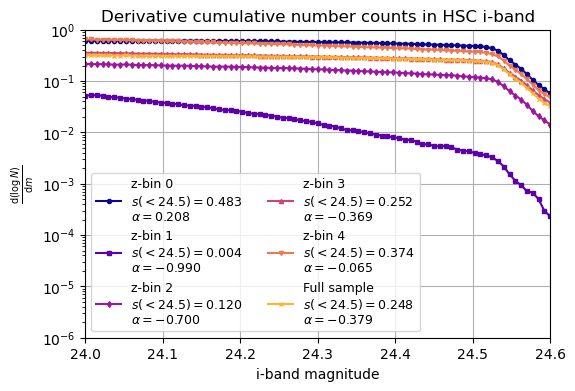

In [ ]:
mag_bins = np.linspace(24, 24.75, 101)
def cumulative_mag_counts(mag, ibmag):
    """Cumulative number counts for magnification bias."""
    return np.array([np.sum(ibmag < m) for m in mag])

# Create cumulative magnitude counts plot using PlotManager
with pm.make_plot('cumulative_mag_counts', figsize=(6, 4)) as (fig, ax):
    dmag = np.gradient(mag_bins)
    markers = ['o', 's', 'd', '^', 'v', 'x']
    for zbin_index in range(0, 6):
        print(f'Processing z-bin {zbin_index}')
        if zbin_index == 5:
            zbin = hsc
            imag = hsc['i_cm_mag'][:] #- hsc['a_i'][:]
        else:
            zbin = hsc[hsc["z_bin"] == zbin_index]
            imag = zbin['i_cm_mag'] #- zbin['a_i']
        print(f'Number of objects in z-bin {zbin_index}: {len(imag)}')
        mag_counts = cumulative_mag_counts(mag_bins, imag)
        dlog_counts = np.gradient(np.log10(mag_counts))
        derivative = dlog_counts / dmag
        s_interp = interp1d(mag_bins, derivative, bounds_error=False, fill_value='extrapolate')
        s_lim = s_interp(24.5)

        ax.plot(
            mag_bins, 
            derivative, 
            marker=markers[zbin_index],
            markersize=3, 
            label=(
                (f'z-bin {zbin_index}' if zbin_index < 5 else 'Full sample') +
                '\n' +
                rf'$s(< 24.5) = {s_lim:.3f}$' + 
                '\n' +
                rf'$\alpha = {2.5 * s_lim - 1:.3f}$'
            ),
            color=cmap_hsc(zbin_index/6),   
            )
    ax.grid(True)
    ax.set_xlabel('i-band magnitude')
    ax.set_ylabel(r'$\frac{\mathrm{d}(\log N)}{\mathrm{d}m}$')
    ax.set_yscale('log')
    ax.set_ylim(1e-6, 1)
    ax.set_xlim(24, 24.6)
    ax.set_title('Derivative cumulative number counts in HSC i-band')
    ax.legend(loc='lower left', fontsize=9, ncols=2)

Number of objects in z-bin 0: 9146157
Number of objects in z-bin 1: 5889826
Number of objects in z-bin 2: 8445233
Number of objects in z-bin 3: 7023314
Number of objects in z-bin 4: 3902504
Number of objects in z-bin 5: 34407034


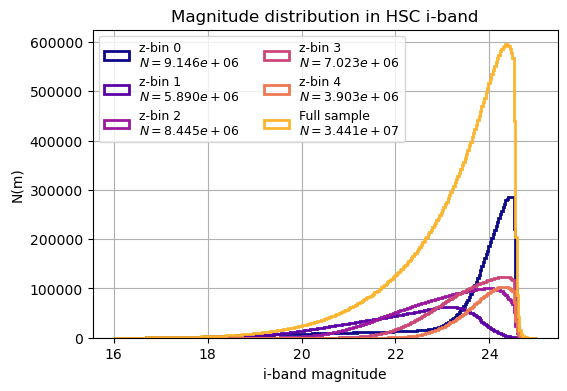

In [ ]:
## magnitude distributions for each z-bin
mag_bins_hist = np.linspace(16, 25, 301)

# Create magnitude distribution plot using PlotManager
with pm.make_plot('magnitude_distribution', figsize=(6, 4)) as (fig, ax):
    for zbin_index in range(0, 6):
        if zbin_index == 5:
            zbin = hsc
            imag = hsc['i_cm_mag'][:] - hsc['a_i'][:]
        else:
            zbin = hsc[hsc["z_bin"] == zbin_index]
            imag = zbin['i_cm_mag'][:] - zbin['a_i'][:]
        print(f'Number of objects in z-bin {zbin_index}: {len(imag)}')
        ax.hist(
            imag, 
            bins=mag_bins_hist, 
            histtype='step', 
            label=(
                (
                    f'z-bin {zbin_index}' 
                    if zbin_index < 5 
                    else 'Full sample'
                    )
                + '\n' +
                rf'$N = {len(imag):.3e}$'
            ),
            color=cmap_hsc(zbin_index/6), 
            linewidth=2
        )
    ax.grid(True)
    ax.set_xlabel('i-band magnitude')
    ax.set_ylabel('N(m)')
    ax.set_title('Magnitude distribution in HSC i-band')
    ax.legend(loc='upper left', fontsize=9, ncols=2)